# MUSA 6500 Final Project - Gun Violence Prediction in Philadelphia
By: Hon Kiu (James) To


**<u>Introduction:</u>**
Gun violence in Philadelphia has been a persistent and deeply complex crisis, affecting thousands of residents each year and leaving a profound impact on victims, families, and entire communities.
According to the shooting victims data, available at [OpenDataPhilly](https://opendataphilly.org/datasets/shooting-victims/), since 2019, nearly 10,000 shootings have been recorded across the city, resulting in over 11,000 victims.
While recent years have seen a notable decline in both homicides and shootings, with shootings in particular dropped by 54% from their 2021 peaks (https://whyy.org/articles/philadelphia-gun-violence-homicide-rate-drops/), Philadelphia continues to grapple with the far-reaching consequences of gun violence.

The burden of gun violence in Philadelphia is not evenly distributed.
Certain neighborhoods, particularly in North, South, and West Philadelphia, face disproportionately higher rates of shootings, often linked to longstanding socioeconomic challenges such as poverty, unemployment, housing insecurity, and limited educational opportunities.
These structural inequities contribute to the persistence of violence and complicate efforts at prevention and intervention.
City leaders and community organizations have responded with a range of strategies, from increased law enforcement initiatives to community-based violence interruption programs and policy reforms.
Recent progress, including a 37% drop in homicides in 2024 compared to the previous year, has been attributed to coordinated efforts between the police department and local government, as well as the engagement of community leaders and residents.
However, officials and advocates emphasize that every life lost is a tragedy, and the city must continue to innovate and invest in evidence-based solutions to sustain these improvements and address the root causes of violence. (https://whyy.org/articles/philadelphia-gun-violence-homicide-rate-drops/)

Given the complexity and urgency of the issue, timely and data-driven resource allocation is crucial for effective gun violence prevention in Philadelphia.
Predictive modeling can play a key role in identifying high-risk areas and periods, enabling policymakers and community organizations to target interventions where they are needed most.
By leveraging the rich datasets available and integrating multidisciplinary perspectives, this project aims to contribute to the ongoing efforts to make Philadelphia safer for all its residents.

**<u>Modeling Strategy:</u>**
Understanding and predicting gun violence in Philadelphia requires careful consideration of its spatial dynamics.
Prior research and empirical observations have established that shootings are not randomly distributed across the city.
Rather, they exhibit strong spatial autocorrelation and clustering.
This means that incidents of gun violence are more likely to occur near other incidents, and certain neighborhoods or districts experience persistently higher rates than others.

To capture these spatial patterns, this project employs a Geographically-Weighted Poisson Regression (GWPR) framework, with police districts serving as the spatial unit of analysis.
The decision to use police districts is both practical and policy-relevant: these administrative boundaries are commonly used for resource allocation, law enforcement deployment, and public safety interventions.
Modeling at this level ensures that the findings are directly actionable for city agencies and stakeholders.

The Poisson regression model is particularly well-suited for this analysis, as it is designed to handle count data, specifically, the number of shootings within each district and time period.
By incorporating geographically-weighted regression, the model can account for local variations in the relationships between predictors and shooting counts, effectively capturing spatial heterogeneity and dependence.

**<u>Covariates and Model Specificaitons:</u>**
To predict shooting counts, the following covariates are included:
- **<u>1-lagged Kernel Density Estimate (KDE):</u>** Measures the intensity of shootings in the previous time period, capturing spatial and temporal autocorrelation.
- **<u>1-lagged Normalized Difference Vegetation Index (NDVI):</u>** Proxy for green space and environmental quality, which have been linked to crime rates.
- **<u>1-lagged Normalized Difference Built-up Index (NDBI):</u>** Reflects urbanization and built environment, another factor associated with crime patterns.
- **<u>Year of Shooting:</u>** Controls for long-term trends and policy changes over time.
- **<u>Quarter of Shooting (categorical):</u>** Captures seasonal effects and temporal fluctuations within each year.

**<u>Model Comparison:</u>**
To assess the contribution of environmental covariates and spatial predictors, two models are estimated:
- **<u>Model 1 (Baseline):</u>** This model uses only 1-lagged KDE, year of shooting, and quarter of shooting as covariates.
This model evaluates the explanatory power of recent shooting intensity and temporal controls, serving as a benchmark for spatial autocorrelation effects.
- **<u>Model 2 (Extended):</u>** This model adds the 1-lagged NDVI and NDBI to the predictors in Model 1.
This model tests whether incorporating environmental and urbanization measures improves predictive accuracy and provides additional insights into the determinants of gun violence.

**<u>Theoretical Framework:</u>**
This modeling approach is grounded in **crime pattern theory** and **environmental criminology**, which emphasize the importance of spatial context, routine activities, and environmental features in shaping crime risk.
By integrating spatially explicit predictors and leveraging advanced statistical techniques, the analysis aims to uncover actionable patterns that can inform targeted interventions and resource allocation.

In [2]:
!pip install mgwr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.2/388.2 kB 23.7 MB/s eta 0:00:00


In [52]:
# Load all necessary libraries
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import geopandas as gpd
import copy
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from shapely.geometry import Point
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from itertools import product
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
from spglm.family import Poisson
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# The following are colab-specific
from google.colab import drive

drive.mount("/content/drive")

pd.set_option('display.max_columns', None)

# pd.reset_option('display.max_columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
philly_police_districts = gpd.read_file("/content/drive/MyDrive/MUSA6500/Boundaries_District.geojson").to_crs(epsg = 2272)
philly_shootings = gpd.read_file("/content/drive/MyDrive/MUSA6500/shootings.geojson").to_crs(epsg = 2272)

**<u>Remark:</u>**
Starting from May 1, 2024, the 6th Police District was officially merged with the 9th Police District.
Since the police district boundaries dataset on [OpenDataPhilly](https://opendataphilly.org/datasets/police-districts/) contains only the latest boundaries, and I cannot find the historical police district boundaries that contain the 6th Police District, I decided to re-allocate all the shootings occurred in the 6th Police District to the 9th Police District across the entire study period (from 2019 onwards).

In [5]:
philly_shootings["dist"] = philly_shootings["dist"].replace("6", "9")

In [6]:
philly_shootings["year_shooting"] = philly_shootings["date_"].dt.year
philly_shootings["quarter_shooting"] = philly_shootings["date_"].dt.quarter
philly_shootings.head()

,objectid,year,dc_key,code,date_,race,sex,age,wound,officer_involved,offender_injured,offender_deceased,location,latino,point_x,point_y,dist,inside,outside,fatal,geometry,year_shooting,quarter_shooting
0,534141,2015,201524094239.00000000,400,2015-09-30 00:00:00+00:00,B,M,33,Back,N,N,N,2200 BLOCK E Westmoreland St,0.0,-75.106083,39.992237,24,0.0,1.0,0.0,POINT (2709194.528 251118.078),2015,3
1,534142,2015,201525061574.00000000,400,2015-07-27 00:00:00+00:00,B,M,24,Leg,N,N,N,5000 BLOCK Boudinot St,1.0,-75.116512,40.025759,25,0.0,1.0,0.0,POINT (2705909.608 263236.835),2015,3
2,534143,2015,201525090029.00000000,400,2015-11-01 00:00:00+00:00,B,M,14,Leg,N,N,N,100 BLOCK W Luzerne St,0.0,-75.126649,40.010813,25,0.0,1.0,0.0,POINT (2703233.669 257710.184),2015,4
3,534144,2015,201539056991.00000000,400,2015-07-14 00:00:00+00:00,B,M,70,Foot,N,N,N,2900 BLOCK N 26th St,0.0,-75.173254,39.999944,39,0.0,1.0,0.0,POINT (2690300.046 253368.179),2015,3
4,534145,2015,201539084412.00000000,400,2015-10-20 00:00:00+00:00,B,M,13,Multiple,N,N,N,3500 BLOCK N 18th St,0.0,-75.158294,40.007025,39,0.0,1.0,0.0,POINT (2694413.763 256069.182),2015,4


Here we only analyze shootings from 2019 onwards since the Sentinel-2 satellite images are available since 2019 (last checked with the Google Earth Engine).

In [7]:
philly_shootings = philly_shootings[philly_shootings["year_shooting"] >= 2019]

`dc_key` is the unique incident identifier.
Notice that the nature of the dataset is <i>shooting victims</i>, so that each row corresponds to a shooting victim.
Since there could be multiple victims in a single shooting, and I am interested in <i>shooting incidents</i>, I drop duplicated records by `dc_key` to ensure that I do not over-count the number of shooting incidents.

In [8]:
philly_shootings = philly_shootings[philly_shootings["point_x"].notna()]
philly_shootings = philly_shootings.drop_duplicates(subset = ["dc_key"])

In [9]:
philly_shootings.shape

(9829, 23)

In [10]:
# Add centroids to police districts before spatial join
philly_police_districts["centroid"] = philly_police_districts.geometry.centroid

# Perform join with rsuffix to retain district geometry
shootings_with_districts = gpd.sjoin(
    philly_shootings,
    philly_police_districts.rename_geometry("district_geo"),
    how = "left",
    predicate = "within"
)

In [11]:
# Keep centroids and shooting coordinates
columns_to_keep = ["dc_key", "year_shooting", "quarter_shooting", "dist", "geometry", "centroid"]
shootings_gdf = shootings_with_districts[columns_to_keep].copy()

# Convert centroids to separate columns
shootings_gdf["centroid_x"] = shootings_gdf["centroid"].x
shootings_gdf["centroid_y"] = shootings_gdf["centroid"].y
shootings_gdf.head()

,dc_key,year_shooting,quarter_shooting,dist,geometry,centroid,centroid_x,centroid_y
1168,2104.00000000,2021,2,35,POINT (2697679.381 266458.543),POINT (2700022.439 268240.078),2.700022e+06,268240.078257
1238,202124058871.00000000,2021,3,24,POINT (2704090.573 250296.636),POINT (2710784.9 251048.829),2.710785e+06,251048.829448
1240,202317020041.00000000,2023,3,17,POINT (2683866.074 230205.464),POINT (2687815.209 230599.95),2.687815e+06,230599.949792
1241,202239008996.00000000,2022,1,39,POINT (2694420.465 253673.553),POINT (2689432.706 258462.406),2.689433e+06,258462.406474
1242,202239009693.00000000,2022,1,39,POINT (2695442.695 260249.289),POINT (2689432.706 258462.406),2.689433e+06,258462.406474


In [12]:
# Calculate KDE at incident locations
coords_meters = np.vstack([shootings_gdf.geometry.x, shootings_gdf.geometry.y]).T

# Bandwidth optimization
params = {"bandwidth": np.linspace(250, 2000, 20).astype(int)}
grid = GridSearchCV(KernelDensity(metric = "euclidean"), params, cv = 5)
grid.fit(coords_meters)
best_bandwidth = grid.best_params_["bandwidth"]

# Apply KDE
kde = KernelDensity(bandwidth = best_bandwidth, metric = "euclidean")
kde.fit(coords_meters)
shootings_gdf["KDE_raw"] = np.exp(kde.score_samples(coords_meters))

In [13]:
# Aggregate by district-time
district_kde = shootings_gdf.groupby(["year_shooting", "quarter_shooting", "dist"]).agg(
    incident_count = ("dc_key", "count"),
    KDE_mean = ("KDE_raw", "mean"),
    centroid_x = ("centroid_x", "first"),  # Critical for GWR
    centroid_y = ("centroid_y", "first"),
    geometry = ("geometry", "first")
).reset_index()

In [14]:
# Create centroid geometry
district_kde_gdf = gpd.GeoDataFrame(
    district_kde,
    geometry = gpd.points_from_xy(district_kde["centroid_x"], district_kde["centroid_y"]),
    crs = shootings_gdf.crs
)

# Verify CRS
print(district_kde_gdf.crs)  # Should show EPSG:2272 (Pennsylvania South State Plane)

EPSG:2272


In [15]:
# Sort by district and time
district_kde_gdf = district_kde_gdf.sort_values(["dist", "year_shooting", "quarter_shooting"])

# Create lagged KDE
district_kde_gdf["KDE_lag1"] = district_kde_gdf.groupby("dist")["KDE_mean"].shift(1)

# Verify lagging
print(district_kde_gdf[["dist", "year_shooting", "quarter_shooting", "KDE_mean", "KDE_lag1"]].head(8))

    dist  year_shooting  quarter_shooting      KDE_mean      KDE_lag1
0      1           2019                 1  7.823971e-10           NaN
17     1           2019                 2  1.109253e-09  7.823971e-10
37     1           2019                 3  7.904849e-10  1.109253e-09
57     1           2019                 4  7.208740e-10  7.904849e-10
77     1           2020                 1  5.226134e-10  7.208740e-10
97     1           2020                 2  2.288138e-09  5.226134e-10
116    1           2020                 3  8.305765e-10  2.288138e-09
136    1           2020                 4  5.200622e-10  8.305765e-10


In [16]:
# Create complete year-quarter-district grid
all_years = range(2019, 2025)  # Up to 2024
all_quarters = [1, 2, 3, 4]
all_dists = district_kde_gdf["dist"].unique()

full_grid = pd.DataFrame(
    list(product(all_years, all_quarters, all_dists)),
    columns = ["year_shooting", "quarter_shooting", "dist"]
)

# Get unique district centroids
district_centroids = district_kde_gdf.drop_duplicates("dist")[["dist", "centroid_x", "centroid_y"]]

# Merge centroids with full grid
expanded_gdf = pd.merge(
    full_grid,
    district_centroids,
    on = "dist",
    how = "left"
)

# Merge shooting data (preserves original geometry where exists)
expanded_gdf = pd.merge(
    expanded_gdf,
    district_kde_gdf.drop(columns = ["centroid_x", "centroid_y"]),
    on = ["year_shooting", "quarter_shooting", "dist"],
    how = "left"
)

# Zero-fill shooting metrics
expanded_gdf["KDE_mean"] = expanded_gdf["KDE_mean"].fillna(0)
expanded_gdf["incident_count"] = expanded_gdf["incident_count"].fillna(0)

# Create extended grid including 2025 Q1
extended_years = range(2019, 2026)  # 2019-2025
full_grid_2025 = pd.DataFrame(
    list(product(extended_years, all_quarters, all_dists)),
    columns = ["year_shooting", "quarter_shooting", "dist"]
)

# Filter for 2025 Q1 specifically
grid_2025q1 = full_grid_2025[
    (full_grid_2025["year_shooting"] == 2025) &
    (full_grid_2025["quarter_shooting"] == 1)
]

# Merge with existing data
expanded_gdf = pd.merge(
    full_grid_2025,
    expanded_gdf.drop(columns = ["year_shooting", "quarter_shooting", "dist"]),
    left_index = True,
    right_index = True,
    how = "left"
)

# Forward-fill district attributes
expanded_gdf = expanded_gdf.sort_values(["dist", "year_shooting", "quarter_shooting"])
for col in ["centroid_x", "centroid_y", "geometry"]:
    expanded_gdf[col] = expanded_gdf.groupby("dist")[col].ffill()

In [17]:
# Calculate 2024 Q4 KDE (last observed value)
kde_2024q4 = expanded_gdf[
    (expanded_gdf["year_shooting"] == 2024) &
    (expanded_gdf["quarter_shooting"] == 4)
][["dist", "KDE_mean"]].rename(columns = {"KDE_mean": "KDE_lag1"})

# Merge with 2025 Q1
expanded_gdf = pd.merge(
    expanded_gdf,
    kde_2024q4,
    on = "dist",
    how = "left",
    suffixes = ('', '_2025q1')
)

# Update KDE_lag1 column
expanded_gdf["KDE_lag1"] = expanded_gdf["KDE_lag1"].fillna(expanded_gdf["KDE_lag1_2025q1"])
expanded_gdf = expanded_gdf.drop(columns = "KDE_lag1_2025q1")

In [18]:
# Final validation
assert expanded_gdf["centroid_x"].notna().all()
assert expanded_gdf["centroid_y"].notna().all()
assert expanded_gdf["KDE_lag1"].notna().all()

In [19]:
# Verify no coordinate drift
centroid_variation = expanded_gdf.groupby("dist")[["centroid_x", "centroid_y"]].std()
assert (centroid_variation == 0).all().all()

In [20]:
# Check lagged values
test_case = expanded_gdf[expanded_gdf["dist"] == "1"].sort_values(["year_shooting", "quarter_shooting"])
assert test_case["KDE_lag1"].iloc[1] == test_case["KDE_mean"].iloc[0]

There are no shootings in certain year-quarter in some police districts.
But given that the zero-inflation phenomenon is not too serious (6.3%), it does not call for the use of zero-inflated models.

In [21]:
zero_count = (expanded_gdf["incident_count"] == 0).mean()
print(f"Zero-inflation: {zero_count:.1%}")

Zero-inflation: 6.3%


In [22]:
expanded_gdf = expanded_gdf[
    ((expanded_gdf["year_shooting"] > 2019) |
     ((expanded_gdf["year_shooting"] == 2019) &
      (expanded_gdf["quarter_shooting"] >= 2))) &
    ((expanded_gdf["year_shooting"] < 2025) |
     ((expanded_gdf["year_shooting"] == 2025) &
      (expanded_gdf["quarter_shooting"] <= 1)))
]

In [23]:
expanded_gdf

,year_shooting,quarter_shooting,dist,centroid_x,centroid_y,incident_count,KDE_mean,geometry,KDE_lag1
1,2019,2,1,2.688434e+06,218462.918392,13.0,1.109253e-09,POINT (2688433.761 218462.918),7.823971e-10
2,2019,3,1,2.688434e+06,218462.918392,3.0,7.904849e-10,POINT (2688433.761 218462.918),1.109253e-09
3,2019,4,1,2.688434e+06,218462.918392,4.0,7.208740e-10,POINT (2688433.761 218462.918),7.904849e-10
4,2020,1,1,2.688434e+06,218462.918392,6.0,5.226134e-10,POINT (2688433.761 218462.918),7.208740e-10
5,2020,2,1,2.688434e+06,218462.918392,2.0,2.288138e-09,POINT (2690141.237 247684.366),5.226134e-10
...,...,...,...,...,...,...,...,...,...
580,2024,1,9,2.694367e+06,237956.241920,5.0,3.156983e-10,POINT (2694367.045 237956.242),2.689768e-10
581,2024,2,9,2.694367e+06,237956.241920,4.0,5.129532e-10,POINT (2694367.045 237956.242),3.156983e-10
582,2024,3,9,2.694367e+06,237956.241920,7.0,6.300646e-10,POINT (2694367.045 237956.242),5.129532e-10
583,2024,4,9,2.694367e+06,237956.241920,6.0,3.918952e-10,POINT (2694367.045 237956.242),6.300646e-10


Besides historical KDE, NDVI and NDBI are introduced as additional covariates.
In this project, I calculate NDVI and NDBI using Sentinel-2 satellite images for leveraging their high resolution.

In [24]:
# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project = "musa-6500-spring-2025")

In [25]:
def calculate_ndvi_ndbi(geometry, start_date, end_date):
    """Calculate NDVI and NDBI for a district and time period"""
    # Load Sentinel-2 collection with cloud masking
    s2_col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(geometry)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)))

    # Calculate NDVI and NDBI
    def add_indices(img):
        ndvi = img.normalizedDifference(["B8", "B4"]).rename("NDVI")
        ndbi = img.normalizedDifference(["B11", "B8"]).rename("NDBI")
        return img.addBands([ndvi, ndbi])

    # Process collection
    processed_col = s2_col.map(add_indices).select(["NDVI", "NDBI"])

    # Calculate median values
    median_img = processed_col.median()

    # Extract zonal statistics
    stats = median_img.reduceRegion(
        reducer = ee.Reducer.mean(),
        geometry = geometry,
        scale = 10  # Sentinel-2 resolution
    )

    return stats.getInfo()

In [26]:
philly_police_districts["DIST_NUMC"] = philly_police_districts["DIST_NUMC"].str.lstrip("0")

In [27]:
# Prepare quarterly time ranges
quarters = {
    1: ("01-01", "03-31"),
    2: ("04-01", "06-30"),
    3: ("07-01", "09-30"),
    4: ("10-01", "12-31")
}

# Process each district and time period
results = []
for year in range(2019, 2025):
    for quarter in range(1, 5):
        start_date = f"{year}-{quarters[quarter][0]}"
        end_date = f"{year}-{quarters[quarter][1]}"

        # Process each district
        for district in expanded_gdf["dist"].unique():
            district_geom = philly_police_districts[philly_police_districts["DIST_NUMC"] == district].geometry.iloc[0]
            district_gdf = gpd.GeoDataFrame(geometry = [district_geom], crs = philly_police_districts.crs)
            ee_geom = geemap.geopandas_to_ee(district_gdf)

            try:
                stats = calculate_ndvi_ndbi(ee_geom, start_date, end_date)
                results.append({
                    "year": year,
                    "quarter": quarter,
                    "dist": district,
                    "NDVI": stats.get("NDVI"),
                    "NDBI": stats.get("NDBI")
                })
            except Exception as e:
                print(f"Error processing {year} Q{quarter} District {district}: {str(e)}")
                results.append({
                    "year": year,
                    "quarter": quarter,
                    "dist": district,
                    "NDVI": None,
                    "NDBI": None
                })

In [28]:
ndvi_ndbi_df = pd.DataFrame(results)
ndvi_ndbi_df

,year,quarter,dist,NDVI,NDBI
0,2019,1,1,0.007682,0.028374
1,2019,1,12,0.131704,0.050051
2,2019,1,14,0.325486,0.038596
3,2019,1,15,0.105924,0.059849
4,2019,1,16,0.205482,0.064597
...,...,...,...,...,...
499,2024,4,5,0.503173,-0.066811
500,2024,4,7,0.410450,-0.046223
501,2024,4,77,0.126103,0.050740
502,2024,4,8,0.298511,-0.008125


In [29]:
# Function to get the previous quarter (and adjust year if needed)
def next_quarter(year, quarter):
    if quarter == 4:
        return (year + 1, 1)
    else:
        return (year, quarter + 1)

# Apply to each row
ndvi_ndbi_df['year_lag'] = ndvi_ndbi_df['year']
ndvi_ndbi_df['quarter_lag'] = ndvi_ndbi_df['quarter']
ndvi_ndbi_df[['year_lag', 'quarter_lag']] = ndvi_ndbi_df.apply(
    lambda row: next_quarter(row['year'], row['quarter']),
    axis=1, result_type='expand'
)

ndvi_ndbi_df

,year,quarter,dist,NDVI,NDBI,year_lag,quarter_lag
0,2019,1,1,0.007682,0.028374,2019,2
1,2019,1,12,0.131704,0.050051,2019,2
2,2019,1,14,0.325486,0.038596,2019,2
3,2019,1,15,0.105924,0.059849,2019,2
4,2019,1,16,0.205482,0.064597,2019,2
...,...,...,...,...,...,...,...
499,2024,4,5,0.503173,-0.066811,2025,1
500,2024,4,7,0.410450,-0.046223,2025,1
501,2024,4,77,0.126103,0.050740,2025,1
502,2024,4,8,0.298511,-0.008125,2025,1


In [31]:
# Convert to DataFrame and merge
expanded_gdf = expanded_gdf.merge(
    ndvi_ndbi_df,
    left_on = ["year_shooting", "quarter_shooting", "dist"],
    right_on = ["year_lag", "quarter_lag", "dist"],
    how = "left"
)

expanded_gdf = expanded_gdf.drop(columns = ["year", "quarter", "year_lag", "quarter_lag"])

expanded_gdf = expanded_gdf.rename(columns = {
    "NDVI": "NDVI_lag1",
    "NDBI": "NDBI_lag1"
})

expanded_gdf

,year_shooting,quarter_shooting,dist,centroid_x,centroid_y,incident_count,KDE_mean,geometry,KDE_lag1,NDVI_lag1,NDBI_lag1
0,2019,2,1,2.688434e+06,218462.918392,13.0,1.109253e-09,POINT (2688433.761 218462.918),7.823971e-10,0.007682,0.028374
1,2019,3,1,2.688434e+06,218462.918392,3.0,7.904849e-10,POINT (2688433.761 218462.918),1.109253e-09,0.113082,-0.040282
2,2019,4,1,2.688434e+06,218462.918392,4.0,7.208740e-10,POINT (2688433.761 218462.918),7.904849e-10,0.161581,-0.065508
3,2020,1,1,2.688434e+06,218462.918392,6.0,5.226134e-10,POINT (2688433.761 218462.918),7.208740e-10,0.053703,-0.046425
4,2020,2,1,2.688434e+06,218462.918392,2.0,2.288138e-09,POINT (2690141.237 247684.366),5.226134e-10,-0.018155,0.079368
...,...,...,...,...,...,...,...,...,...,...,...
499,2024,1,9,2.694367e+06,237956.241920,5.0,3.156983e-10,POINT (2694367.045 237956.242),2.689768e-10,0.137200,-0.004992
500,2024,2,9,2.694367e+06,237956.241920,4.0,5.129532e-10,POINT (2694367.045 237956.242),3.156983e-10,0.087457,0.035747
501,2024,3,9,2.694367e+06,237956.241920,7.0,6.300646e-10,POINT (2694367.045 237956.242),5.129532e-10,0.189078,-0.004516
502,2024,4,9,2.694367e+06,237956.241920,6.0,3.918952e-10,POINT (2694367.045 237956.242),6.300646e-10,0.176589,-0.020434


In [32]:
expanded_gdf = gpd.GeoDataFrame(expanded_gdf, geometry = "geometry")

In [33]:
# Only fill rows where geometry is missing (None or NaN)
mask = expanded_gdf["geometry"].isna()
expanded_gdf.loc[mask, "geometry"] = expanded_gdf[mask].apply(
    lambda row: Point(row["centroid_x"], row["centroid_y"]),
    axis = 1
)

In [35]:
expanded_gdf.to_parquet("/content/drive/MyDrive/MUSA6500/philly_shootings_data_with_covariates.parquet")

In [ ]:
expanded_gdf.read_parquet("/content/drive/MyDrive/MUSA6500/philly_shootings_data_with_covariates.parquet")

In [34]:
# Filter training period (2019 Q2 - 2023 Q4)
train_set = expanded_gdf[
    (expanded_gdf["year_shooting"] > 2019) |
    ((expanded_gdf["year_shooting"] == 2019) & (expanded_gdf["quarter_shooting"] >= 2))
].copy()
train_set = train_set[train_set["year_shooting"] < 2024].copy()

# Prepare test set (2024)
test_set = expanded_gdf[
    (expanded_gdf["year_shooting"] == 2024)
].copy()

# Forecast for 2025 Q1
forecast_set = expanded_gdf[
    (expanded_gdf["year_shooting"] == 2025)
].copy()

## Model 1 - Baseline Model
Recall that this model uses only 1-lagged KDE, year of shooting, and quarter of shooting as covariates.
It is used to evaluate the explanatory power of recent shooting intensity and temporal controls, serving as a benchmark for spatial autocorrelation effects.

In [38]:
X_train_base = pd.concat([
    train_set[["KDE_lag1"]].copy(),
    train_set[["year_shooting"]].copy(),
    pd.get_dummies(train_set["quarter_shooting"], prefix = "q", drop_first = True)
], axis = 1)

# 2. Scale KDE_lag1
scaler = StandardScaler()
X_train_base["KDE_lag1"] = scaler.fit_transform(X_train_base[["KDE_lag1"]])

# 3. Convert to numpy AFTER feature engineering
X_train_base = X_train_base.astype(float).to_numpy()
y_train_base = train_set["incident_count"].values.reshape(-1, 1)
coords = list(zip(train_set.geometry.x, train_set.geometry.y))

In [42]:
# ====================== CV PREDICTION FIXES ======================
cv_errors = []
unique_districts = train_set["dist"].unique()
district_ids = train_set["dist"].values

# Define candidate bandwidths
candidate_bandwidths = np.linspace(50, 350, 10)

for bw in candidate_bandwidths:
    fold_errors = []
    print(f"Evaluating bandwidth: {bw:.2f}")

    for district in unique_districts:
        test_mask = district_ids == district
        train_mask = ~test_mask
        # print(X_train_base[train_mask].shape[1], X_train_base[test_mask].shape[1])  # MUST MATCH

        # Prepare training data for this fold
        coords_train = np.array(coords)[train_mask]
        y_train_base_cv = y_train_base[train_mask]
        X_train_base_cv = X_train_base[train_mask]

        # Prepare test data for this fold
        coords_test = np.array(coords)[test_mask]
        y_test_base_cv = y_train_base[test_mask]
        X_test_base_cv = X_train_base[test_mask]

        model = GWR(
            coords_train,
            y_train_base_cv,
            X_train_base_cv,
            bw,  # USE FOLD-SPECIFIC BANDWIDTH
            family = Poisson(),
            fixed = False
        )
        results = model.fit()

        # 5. Use EXP transformation for Poisson predictions
        pred = model.predict(
            coords_test,
            P = X_test_base_cv
        )
        y_pred = np.exp(pred.predictions).flatten()

        # Compute error metric (e.g., RMSE)
        rmse = np.sqrt(mean_squared_error(y_test_base_cv.flatten(), y_pred))
        fold_errors.append(rmse)

    # Average error across folds for this bandwidth
    avg_rmse = np.mean(fold_errors)
    cv_errors.append(avg_rmse)
    print(f"Avg RMSE for bandwidth {bw:.2f}: {avg_rmse:.4f}")

# Select bandwidth with lowest average CV error
best_bw = candidate_bandwidths[np.argmin(cv_errors)]
print(f"\nOptimal bandwidth selected by CV: {best_bw:.2f}")

Evaluating bandwidth: 50.00
Avg RMSE for bandwidth 50.00: 40.1633
Evaluating bandwidth: 83.33
Avg RMSE for bandwidth 83.33: 25.5282
Evaluating bandwidth: 116.67
Avg RMSE for bandwidth 116.67: 25.3758
Evaluating bandwidth: 150.00
Avg RMSE for bandwidth 150.00: 24.1053
Evaluating bandwidth: 183.33
Avg RMSE for bandwidth 183.33: 24.9025
Evaluating bandwidth: 216.67
Avg RMSE for bandwidth 216.67: 24.9144
Evaluating bandwidth: 250.00
Avg RMSE for bandwidth 250.00: 24.9238
Evaluating bandwidth: 283.33
Avg RMSE for bandwidth 283.33: 25.6493
Evaluating bandwidth: 316.67
Avg RMSE for bandwidth 316.67: 26.0379
Evaluating bandwidth: 350.00
Avg RMSE for bandwidth 350.00: 27.8330

Optimal bandwidth selected by CV: 150.00


In [44]:
# Now fit final model with best bandwidth on full data
final_model = GWR(np.array(coords), y_train_base, X_train_base, best_bw, family = Poisson(), fixed = False)
final_results = final_model.fit()

In [45]:
final_results.summary()

Model type                                                          Poisson
Number of observations:                                                 399
Number of covariates:                                                     6

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          3967.922
Log-likelihood:                                                   -2831.474
AIC:                                                               5674.949
AICc:                                                              3980.136
BIC:                                                               1614.260
Percent deviance explained:                                           0.386
Adj. percent deviance explained:                                      0.378

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [47]:
# 7. Map coefficients to features
feature_names = ["intercept", "KDE_lag1", "year_shooting"] + \
               [f"q_{q}" for q in range(2,5)]

coef_df = pd.DataFrame(final_results.params, columns = feature_names)
coef_df.drop_duplicates()

,intercept,KDE_lag1,year_shooting,q_2,q_3,q_4
0,146.464809,0.731460,-0.071235,0.249293,0.112829,0.137630
4,-39.161771,1.225667,0.020691,0.151955,0.141685,-0.060683
19,184.340796,1.001845,-0.089860,0.229726,0.094049,0.138386
38,97.075351,0.807398,-0.046444,0.095296,0.115258,-0.149487
57,39.257152,0.222644,-0.017859,0.132495,0.094329,0.151318
76,61.705683,1.046121,-0.029159,0.050130,0.246616,-0.020820
95,138.369246,0.560113,-0.067313,0.138244,0.316732,0.089805
114,160.119602,0.903013,-0.077859,0.026112,0.326635,0.013589
133,96.046272,0.780749,-0.046073,0.007948,0.292981,0.019718
152,21.849386,0.312859,-0.009277,0.108951,0.045116,0.097518


In [48]:
X_test_base = pd.concat([
    test_set[["KDE_lag1"]].copy(),
    test_set[["year_shooting"]].copy(),
    pd.get_dummies(test_set["quarter_shooting"], prefix = "q", drop_first = True)
], axis = 1)

# 2. Scale KDE_lag1
X_test_base["KDE_lag1"] = scaler.transform(X_test_base[["KDE_lag1"]])

# 3. Convert to numpy AFTER feature engineering
X_test_base = X_test_base.astype(float).to_numpy()
y_test_base = test_set["incident_count"].values.reshape(-1, 1)
coords_2024 = list(zip(test_set.geometry.x, test_set.geometry.y))

In [58]:
final_model_2024 = copy.deepcopy(final_model)
final_model_2025 = copy.deepcopy(final_model)

In [59]:
final_results_2024 = final_model_2024.fit()
final_results_2025 = final_model_2025.fit()

In [62]:
pred_2024_gwr = final_model_2024.predict(np.array(coords_2024), P = X_test_base)

In [66]:
pred_2024_gwr.predictions.shape

(84, 1)

In [82]:
y_pred_2024 = np.exp(pred_2024_gwr.predictions).flatten()

# Compute error metric
rmse_2024 = np.sqrt(mean_squared_error(y_test_base.flatten(), y_pred_2024))
print(f"RMSE for 2024: {rmse_2024:.4f}")

RMSE for 2024: 11.5385


In [74]:
# Expected dummy columns from training (quarters 2, 3, 4)
expected_quarters = ["q_2", "q_3", "q_4"]

# Create dummies for forecast set
dummies_forecast = pd.get_dummies(forecast_set["quarter_shooting"], prefix = "q", drop_first = True)

# Reindex to ensure all expected dummy columns are present, fill missing with 0
dummies_forecast = dummies_forecast.reindex(columns = expected_quarters, fill_value = 0)

# Now build X_forecast_base with all features aligned
X_forecast_base = pd.concat([
    forecast_set[["KDE_lag1"]].copy(),
    forecast_set[["year_shooting"]].copy(),
    dummies_forecast
], axis=1)

# 2. Scale KDE_lag1
X_forecast_base["KDE_lag1"] = scaler.transform(X_forecast_base[["KDE_lag1"]])

# 3. Convert to numpy AFTER feature engineering
X_forecast_base = X_forecast_base.astype(float).to_numpy()
coords_2025 = list(zip(forecast_set.geometry.x, forecast_set.geometry.y))

In [78]:
pred_2025_gwr = final_model_2025.predict(np.array(coords_2025), P = X_forecast_base)

In [80]:
pred_2025_gwr.predictions.shape

(21, 1)

In [92]:
forecast_set_with_predictions = forecast_set.copy()

In [94]:
forecast_set_with_predictions["predicted_count"] = np.exp(pred_2025_gwr.predictions).flatten()

In [95]:
forecast_set_with_predictions

,year_shooting,quarter_shooting,dist,centroid_x,centroid_y,incident_count,KDE_mean,geometry,KDE_lag1,NDVI_lag1,NDBI_lag1,predicted_count
23,2025,1,1,2.688434e+06,218462.918392,NaN,NaN,POINT (2688433.761 218462.918),1.034853e-09,0.074486,-0.018688,10.259544
47,2025,1,12,2.676041e+06,218673.720567,NaN,NaN,POINT (2676041.248 218673.721),8.237142e-10,0.251485,-0.017484,9.610126
71,2025,1,14,2.685762e+06,274775.519876,NaN,NaN,POINT (2685762.102 274775.52),4.919077e-10,0.469443,-0.075489,13.414002
95,2025,1,15,2.721612e+06,261951.208923,NaN,NaN,POINT (2721611.972 261951.209),8.650895e-10,0.164655,0.009980,21.731347
119,2025,1,16,2.682030e+06,244722.408849,NaN,NaN,POINT (2682029.84 244722.409),1.196158e-09,0.379608,-0.032887,20.857538
143,2025,1,17,2.687815e+06,230599.949792,NaN,NaN,POINT (2687815.209 230599.95),6.508731e-10,0.146744,0.039414,6.526594
167,2025,1,18,2.678164e+06,235406.842081,NaN,NaN,POINT (2678163.512 235406.842),9.526337e-10,0.236594,0.017390,12.207434
191,2025,1,19,2.672265e+06,245975.125902,NaN,NaN,POINT (2672265.175 245975.126),1.190815e-09,0.346402,-0.023204,20.604080
215,2025,1,2,2.715442e+06,272358.045920,NaN,NaN,POINT (2715441.877 272358.046),2.120216e-10,0.262001,0.011707,16.215756
239,2025,1,22,2.690141e+06,247684.366086,NaN,NaN,POINT (2690141.237 247684.366),1.633196e-09,0.256870,0.012791,47.595540


In [103]:
districts_with_pred_base = philly_police_districts.merge(
    forecast_set_with_predictions,
    left_on = "DIST_NUMC",
    right_on = "dist",
    how = "left"
)

In [107]:
districts_with_pred_base = districts_with_pred_base.set_geometry("geometry_x", inplace = False)

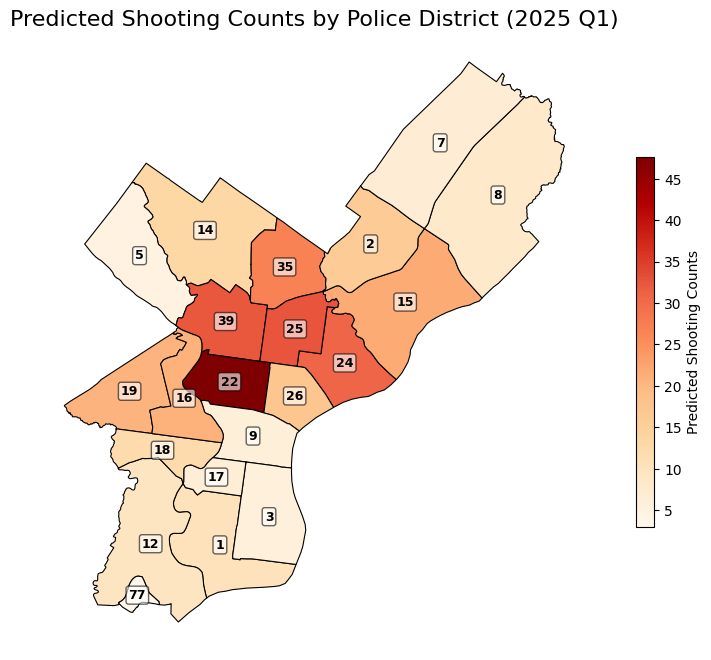

In [132]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

districts_with_pred_base.plot(
    column = "predicted_count",  # Column with predictions
    cmap = "OrRd",               # Color map (orange-red)
    linewidth = 0.8,
    edgecolor = "black",
    legend = True,
    legend_kwds = {'label': "Predicted Shooting Counts", 'shrink': 0.6},
    ax = ax
)

# Add district number labels at centroids
for idx, row in districts_with_pred_base.iterrows():
    # Get centroid coordinates
    x, y = row["geometry_x"].centroid.x, row["geometry_x"].centroid.y
    # Get district number (adjust column name if different)
    district_num = row["DIST_NUMC"]
    # Annotate on the plot
    ax.text(x, y, str(district_num), fontsize = 9, fontweight = "bold",
            ha = "center", va = "center", color = "black",
            bbox = dict(facecolor = "white", alpha = 0.6, boxstyle = "round,pad=0.2"))

ax.set_title("Predicted Shooting Counts by Police District (2025 Q1)", fontsize = 16)
ax.axis("off")

# Save the figure as a PDF file
fig.savefig("/content/drive/MyDrive/MUSA6500/predicted_shooting_counts_2025Q1_base.pdf", format = "pdf", bbox_inches = "tight")

plt.show()

## Model 2 - Extended Model
This model adds the 1-lagged NDVI and NDBI to the predictors in Model 1.
It tests whether incorporating environmental and urbanization measures improves predictive accuracy and provides additional insights into the determinants of gun violence.

In [111]:
X_train_full = pd.concat([
    train_set[["KDE_lag1"]].copy(),
    train_set[["NDVI_lag1"]].copy(),
    train_set[["NDBI_lag1"]].copy(),
    train_set[["year_shooting"]].copy(),
    pd.get_dummies(train_set["quarter_shooting"], prefix = "q", drop_first = True)
], axis = 1)

# 2. Scale KDE_lag1
scaler = StandardScaler()
X_train_full[["KDE_lag1", "NDVI_lag1", "NDBI_lag1"]] = scaler.fit_transform(X_train_full[["KDE_lag1", "NDVI_lag1", "NDBI_lag1"]])

# 3. Convert to numpy AFTER feature engineering
X_train_full = X_train_full.astype(float).to_numpy()
y_train_full = train_set["incident_count"].values.reshape(-1, 1)
coords_full = list(zip(train_set.geometry.x, train_set.geometry.y))

In [112]:
# ====================== CV PREDICTION FIXES ======================
cv_errors = []
unique_districts = train_set["dist"].unique()
district_ids = train_set["dist"].values

# Define candidate bandwidths
candidate_bandwidths = np.linspace(50, 350, 10)

for bw in candidate_bandwidths:
    fold_errors = []
    print(f"Evaluating bandwidth: {bw:.2f}")

    for district in unique_districts:
        test_mask = district_ids == district
        train_mask = ~test_mask

        # Prepare training data for this fold
        coords_train = np.array(coords)[train_mask]
        y_train_full_cv = y_train_full[train_mask]
        X_train_full_cv = X_train_full[train_mask]

        # Prepare test data for this fold
        coords_test = np.array(coords)[test_mask]
        y_test_full_cv = y_train_full[test_mask]
        X_test_full_cv = X_train_full[test_mask]

        model = GWR(
            coords_train,
            y_train_full_cv,
            X_train_full_cv,
            bw,  # USE FOLD-SPECIFIC BANDWIDTH
            family = Poisson(),
            fixed = False
        )
        results = model.fit()

        # 5. Use EXP transformation for Poisson predictions
        pred = model.predict(
            coords_test,
            P = X_test_full_cv
        )
        y_pred = np.exp(pred.predictions).flatten()

        # Compute error metric
        rmse = np.sqrt(mean_squared_error(y_test_full_cv.flatten(), y_pred))
        fold_errors.append(rmse)

    # Average error across folds for this bandwidth
    avg_rmse = np.mean(fold_errors)
    cv_errors.append(avg_rmse)
    print(f"Avg RMSE for bandwidth {bw:.2f}: {avg_rmse:.4f}")

# Select bandwidth with lowest average CV error
best_bw_full = candidate_bandwidths[np.argmin(cv_errors)]
print(f"\nOptimal bandwidth selected by CV: {best_bw_full:.2f}")

Evaluating bandwidth: 50.00
Avg RMSE for bandwidth 50.00: 15.3903
Evaluating bandwidth: 83.33
Avg RMSE for bandwidth 83.33: 12.8512
Evaluating bandwidth: 116.67
Avg RMSE for bandwidth 116.67: 12.3167
Evaluating bandwidth: 150.00
Avg RMSE for bandwidth 150.00: 13.8307
Evaluating bandwidth: 183.33
Avg RMSE for bandwidth 183.33: 19.0761
Evaluating bandwidth: 216.67
Avg RMSE for bandwidth 216.67: 19.6412
Evaluating bandwidth: 250.00
Avg RMSE for bandwidth 250.00: 19.5719
Evaluating bandwidth: 283.33
Avg RMSE for bandwidth 283.33: 20.3856
Evaluating bandwidth: 316.67
Avg RMSE for bandwidth 316.67: 20.6529
Evaluating bandwidth: 350.00
Avg RMSE for bandwidth 350.00: 22.8619

Optimal bandwidth selected by CV: 116.67


In [113]:
# Now fit final model with best bandwidth on full data
final_model_full = GWR(np.array(coords_full), y_train_full, X_train_full, best_bw_full, family = Poisson(), fixed = False)
final_results_full = final_model_full.fit()

In [114]:
final_results_full.summary()

Model type                                                          Poisson
Number of observations:                                                 399
Number of covariates:                                                     8

Global Regression Results
---------------------------------------------------------------------------
Deviance:                                                          3638.679
Log-likelihood:                                                   -2666.853
AIC:                                                               5349.706
AICc:                                                              3655.048
BIC:                                                               1296.995
Percent deviance explained:                                           0.437
Adj. percent deviance explained:                                      0.427

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [115]:
# 7. Map coefficients to features
feature_names_full = ["intercept", "KDE_lag1", "NDVI_lag1", "NDBI_lag1", "year_shooting"] + \
               [f"q_{q}" for q in range(2,5)]

coef_df_full = pd.DataFrame(final_results_full.params, columns = feature_names_full)
coef_df_full.drop_duplicates()

,intercept,KDE_lag1,NDVI_lag1,NDBI_lag1,year_shooting,q_2,q_3,q_4
0,245.438846,0.175270,1.168277,0.294918,-0.119833,0.580514,-0.162575,-0.334058
4,-44.999905,1.243842,0.181477,0.009291,0.023566,0.262726,0.088381,-0.103928
19,247.234981,0.915565,1.298861,0.218558,-0.120771,0.795813,-0.152473,-0.415403
38,116.651843,0.703503,-0.193156,-0.079640,-0.056052,0.027541,0.077284,-0.170414
57,46.807044,0.191211,-0.115236,0.006589,-0.021602,0.053364,0.135339,0.183450
76,75.854246,0.966790,0.128035,0.134019,-0.036172,-0.052318,0.352832,0.052983
95,129.717022,0.492767,0.362591,0.134533,-0.062958,0.210082,0.344009,0.099691
114,102.509088,0.060573,0.640964,0.373294,-0.049361,0.081530,0.452506,0.121831
133,85.715065,0.678538,0.318347,0.247102,-0.041037,-0.041821,0.491037,0.174936
152,14.330277,0.370732,-0.108012,-0.016072,-0.005531,0.023596,0.018044,0.092319


In [116]:
X_test_full = pd.concat([
    test_set[["KDE_lag1"]].copy(),
    test_set[["NDVI_lag1"]].copy(),
    test_set[["NDBI_lag1"]].copy(),
    test_set[["year_shooting"]].copy(),
    pd.get_dummies(test_set["quarter_shooting"], prefix = "q", drop_first = True)
], axis = 1)

X_test_full[["KDE_lag1", "NDVI_lag1", "NDBI_lag1"]] = scaler.transform(X_test_full[["KDE_lag1", "NDVI_lag1", "NDBI_lag1"]])

# 3. Convert to numpy AFTER feature engineering
X_test_full = X_test_full.astype(float).to_numpy()
y_test_full = test_set["incident_count"].values.reshape(-1, 1)
coords_2024_full = list(zip(test_set.geometry.x, test_set.geometry.y))

In [117]:
final_model_full_2024 = copy.deepcopy(final_model_full)
final_model_full_2025 = copy.deepcopy(final_model_full)

In [118]:
final_results_full_2024 = final_model_full_2024.fit()
final_results_full_2025 = final_model_full_2025.fit()

In [119]:
pred_full_2024_gwr = final_model_full_2024.predict(np.array(coords_2024_full), P = X_test_full)

In [120]:
pred_full_2024_gwr.predictions.shape

(84, 1)

In [121]:
y_pred_full_2024 = np.exp(pred_full_2024_gwr.predictions).flatten()

# Compute error metric
rmse_full_2024 = np.sqrt(mean_squared_error(y_test_full.flatten(), y_pred_full_2024))
print(f"RMSE for 2024 (Full Model): {rmse_full_2024:.4f}")

RMSE for 2024 (Full Model): 11.7227


In [122]:
# Expected dummy columns from training (quarters 2, 3, 4)
expected_quarters = ["q_2", "q_3", "q_4"]

# Create dummies for forecast set
dummies_forecast = pd.get_dummies(forecast_set["quarter_shooting"], prefix = "q", drop_first = True)

# Reindex to ensure all expected dummy columns are present, fill missing with 0
dummies_forecast = dummies_forecast.reindex(columns = expected_quarters, fill_value = 0)

# Now build X_forecast_base with all features aligned
X_forecast_full = pd.concat([
    forecast_set[["KDE_lag1"]].copy(),
    forecast_set[["NDVI_lag1"]].copy(),
    forecast_set[["NDBI_lag1"]].copy(),
    forecast_set[["year_shooting"]].copy(),
    dummies_forecast
], axis = 1)

X_forecast_full[["KDE_lag1", "NDVI_lag1", "NDBI_lag1"]] = scaler.transform(X_forecast_full[["KDE_lag1", "NDVI_lag1", "NDBI_lag1"]])

# 3. Convert to numpy AFTER feature engineering
X_forecast_full = X_forecast_full.astype(float).to_numpy()
y_forecast_full = forecast_set["incident_count"].values.reshape(-1, 1)
coords_2025_full = list(zip(forecast_set.geometry.x, forecast_set.geometry.y))

In [123]:
pred_full_2025_gwr = final_model_full_2025.predict(np.array(coords_2025_full), P = X_forecast_full)

In [124]:
pred_full_2025_gwr.predictions.shape

(21, 1)

In [125]:
forecast_set_with_predictions_full = forecast_set.copy()

In [126]:
forecast_set_with_predictions_full["predicted_count"] = np.exp(pred_full_2025_gwr.predictions).flatten()

In [127]:
forecast_set_with_predictions_full

,year_shooting,quarter_shooting,dist,centroid_x,centroid_y,incident_count,KDE_mean,geometry,KDE_lag1,NDVI_lag1,NDBI_lag1,predicted_count
23,2025,1,1,2.688434e+06,218462.918392,NaN,NaN,POINT (2688433.761 218462.918),1.034853e-09,0.074486,-0.018688,3.783925
47,2025,1,12,2.676041e+06,218673.720567,NaN,NaN,POINT (2676041.248 218673.721),8.237142e-10,0.251485,-0.017484,13.398713
71,2025,1,14,2.685762e+06,274775.519876,NaN,NaN,POINT (2685762.102 274775.52),4.919077e-10,0.469443,-0.075489,12.491176
95,2025,1,15,2.721612e+06,261951.208923,NaN,NaN,POINT (2721611.972 261951.209),8.650895e-10,0.164655,0.009980,22.821997
119,2025,1,16,2.682030e+06,244722.408849,NaN,NaN,POINT (2682029.84 244722.409),1.196158e-09,0.379608,-0.032887,21.304207
143,2025,1,17,2.687815e+06,230599.949792,NaN,NaN,POINT (2687815.209 230599.95),6.508731e-10,0.146744,0.039414,6.765617
167,2025,1,18,2.678164e+06,235406.842081,NaN,NaN,POINT (2678163.512 235406.842),9.526337e-10,0.236594,0.017390,15.031401
191,2025,1,19,2.672265e+06,245975.125902,NaN,NaN,POINT (2672265.175 245975.126),1.190815e-09,0.346402,-0.023204,21.711955
215,2025,1,2,2.715442e+06,272358.045920,NaN,NaN,POINT (2715441.877 272358.046),2.120216e-10,0.262001,0.011707,16.177065
239,2025,1,22,2.690141e+06,247684.366086,NaN,NaN,POINT (2690141.237 247684.366),1.633196e-09,0.256870,0.012791,48.198022


In [128]:
districts_with_pred_full = philly_police_districts.merge(
    forecast_set_with_predictions_full,
    left_on = "DIST_NUMC",
    right_on = "dist",
    how = "left"
)

In [129]:
districts_with_pred_full = districts_with_pred_full.set_geometry("geometry_x", inplace = False)

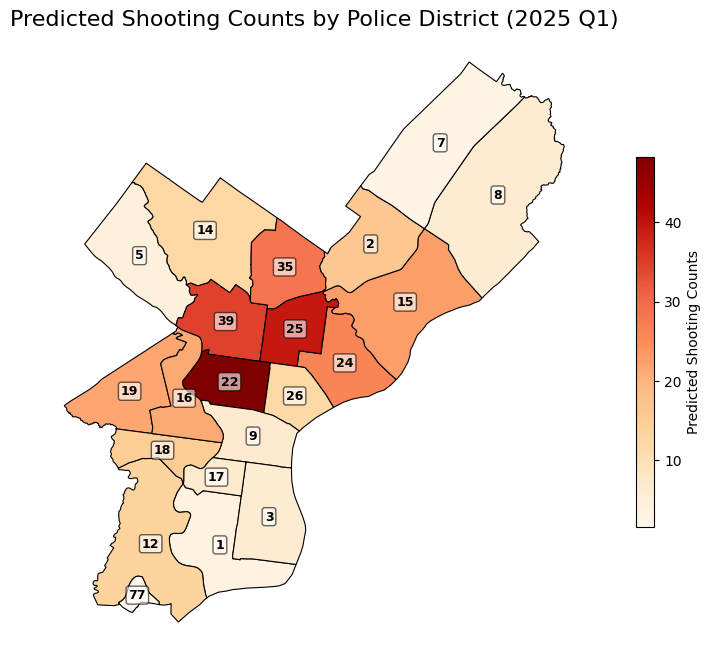

In [131]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

districts_with_pred_full.plot(
    column = "predicted_count",  # Column with predictions
    cmap = "OrRd",               # Color map (orange-red)
    linewidth = 0.8,
    edgecolor = "black",
    legend = True,
    legend_kwds = {'label': "Predicted Shooting Counts", 'shrink': 0.6},
    ax = ax
)

# Add district number labels at centroids
for idx, row in districts_with_pred_base.iterrows():
    # Get centroid coordinates
    x, y = row["geometry_x"].centroid.x, row["geometry_x"].centroid.y
    # Get district number (adjust column name if different)
    district_num = row["DIST_NUMC"]
    # Annotate on the plot
    ax.text(x, y, str(district_num), fontsize = 9, fontweight = "bold",
            ha = "center", va = "center", color = "black",
            bbox = dict(facecolor = "white", alpha = 0.6, boxstyle = "round,pad=0.2"))

ax.set_title("Predicted Shooting Counts by Police District (2025 Q1)", fontsize = 16)
ax.axis("off")

# Save the figure as a PDF file
fig.savefig("/content/drive/MyDrive/MUSA6500/predicted_shooting_counts_2025Q1_full.pdf", format = "pdf", bbox_inches = "tight")

plt.show()

## Discussions, Limitations, and Conclusion
- **<u>Discussions:</u>**
  - Both the baseline model (Model 1) and extended model (Model 2) show significant performance gains when using GWPR compared to traditional global regression approaches.
  This underscores the presence of substantial spatial heterogeneity and dependence in Philadelphia's gun violence patterns, highlighting the necessity of spatially explicit modeling like GWPR.
  - The baseline model (Model 1) explains 68.4% of deviance (adjusted), indicating that historical shooting patterns, when controlled for long-term trends and seasonal effects (via year and quarter of shooting covariates), provide a moderately strong basis for prediction.
  This finding aligns with the crime pattern theory, which posits that crime risk is strongly influenced by recent local events and established spatial routines.
  - The extended model (Model 2), which incorporates lagged measures of environmental features (NDVI and NDBI), explains 78.0% of deviance (adjusted), a notable improvement of nearly 10 percentage points over the baseline.
  This result lends empirical support to environmental criminology perspectives, suggesting that neighborhood characteristics such as green space and urban density may play a meaningful role in shaping crime risk.
  - In both models, nearly all covariates are statistically significant, both at the conventional level of 5% as well as the more stringent 0.5% threshold as suggested by some Statisticians, reinforcing the robustness of the findings.
  - Spatial prediction maps derived from the models indicate that police and policymakers should focus heightened attention on the North and Northeast regions of Philadelphia, especially within the 22nd, 25th, 24th, 39th, 35th, and 15th Police Districts.
  These areas emerge as hotspots for gun violence, warranting targeted interventions and resource allocation.
- **<u>Limitations:</u>**
  - **<u>Event Rarity and Data Granularity:</u>**
  Shootings are relatively rare events, which limits the feasibility of highly granular analyses.
  Although monthly data would offer finer temporal resolution, data sparsity at this level could undermine model reliability and statistical power.
  Quarterly aggregation strikes a balance, allowing for the retention of some seasonal variation through quarter-specific covariates and the calculation of quarterly NDVI and NDBI metrics.
  - **<u>Covariate Scope and Model Complexity:</u>**
  The limited sample size constrains the number of covariates that can be included without risking overfitting or multicollinearity.
  As a result, the present models focus on a select set of theoretically motivated predictors.
  These findings should therefore be interpreted as preliminary evidence in support of environmental criminology, rather than definitive proof.

**<u>Conclusion:</u>**
In summary, while the models offer valuable insights into the spatial and environmental determinants of gun violence in Philadelphia, future research with richer datasets and additional covariates could further refine these findings and enhance their policy relevance.


I consulted Perplexity when developing the codes for this project.